In [8]:
import sys
print(sys.executable)
!{sys.executable} -m pip install langgraph langchain langchain-google-genai

c:\Users\Mahantesh\AppData\Local\Programs\Python\Python312\python.exe
  Using cached langgraph-1.2.11-py3-none-any.whl.metadata (4.9 kB)
  Using cached langchain-1.4.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_core-1.6.3-py3-none-any.whl.metadata (4.8 kB)
  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.met


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [13]:
# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [14]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [15]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [16]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)


# compile the graph
workflow = graph.compile()

In [17]:
# execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


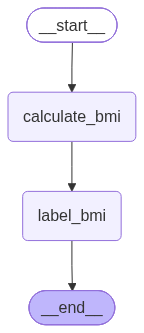

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())